#Start

In [1]:
# Google Drive Permissions
from google.colab import drive
drive.mount('/content/drive')

# Package instalation
%pip install folium
%pip install gurobipy
%pip install pulp
%pip install pykrige
%pip install scipy

# Libs import
import pandas as pd
import os
import numpy as np
import folium
import geopandas as gpd
from pykrige.ok import OrdinaryKriging
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.metrics import mean_absolute_error, mean_squared_error
from geopy.distance import geodesic
import time

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 32.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 43.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 854.9/854.9 kB 7.1 MB/s eta 0:00:00


#Read data

In [2]:
# Diretório dos arquivos
dir_path = "/content/drive/My Drive/Projeto/SJC/2024/"

# Ler os arquivos
localizacoes_file = "localizacoes.xltx"
novas_file = "novas.xlsx"  # Certifique-se de corrigir o nome do arquivo, se necessário

# Caminho completo para os arquivos
localizacoes_path = dir_path + localizacoes_file
novas_path = dir_path + novas_file

# Ler os arquivos em DataFrames
localizacoes_df = pd.read_excel(localizacoes_path)
novas_df = pd.read_excel(novas_path)

# Juntar os DataFrames
novas_loc = pd.merge(localizacoes_df, novas_df[['numero', 'Total']], on='numero')

# Selecionar as colunas desejadas
novas_loc = novas_loc[['nome', 'latitude', 'longitude', 'Total']]

# Renomear as colunas
novas_loc.columns = ['nome', 'latitude', 'longitude', 'Total']

# Exibir o DataFrame final
novas_loc

,nome,latitude,longitude,Total
0,Rio Comprido,-23.25859,-45.94240,345.6
1,Capuava,-23.28499,-45.83325,140.7
2,Vila Nair,-23.21662,-45.88589,200.1
3,São Bento,-23.22675,-45.87754,211.5
4,Campo dos Alemães,-23.27519,-45.90070,137.7
5,Jardim Oriente,-23.23828,-45.89977,319.1
6,Sítio Bom Jesus,-23.21269,-45.84754,205.5
7,Jardim do Lago,-23.24058,-45.84127,219.0
8,Recanto dos Tamoios,-23.27297,-45.79862,123.0
9,Vila Corintinha,-23.18741,-45.86531,127.2


# Algorithms

##IDW

In [ ]:
# Define a função de criar um grid de novas localizações
def NovasLocalizacoes(df_t, n, expand):
  # Calcula os limites das localizações existentes em latitude e longitude
  lat_min = df_t['latitude'].min()
  lat_max = df_t['latitude'].max()
  lon_min = df_t['longitude'].min()
  lon_max = df_t['longitude'].max()
  # Expande os limites de acordo com o valor de expand
  lat_range = lat_max - lat_min
  lon_range = lon_max - lon_min
  lat_min = lat_min - expand * lat_range
  lat_max = lat_max + expand * lat_range
  lon_min = lon_min - expand * lon_range
  lon_max = lon_max + expand * lon_range
  # Cria n novas localizações geográficas em cada direção, formando um grid quadrado
  new_lats = np.linspace(lat_min, lat_max, n)
  new_lons = np.linspace(lon_min, lon_max, n)
  new_locs = np.meshgrid(new_lats, new_lons)
  # Cria um dataframe com as novas localizações e os nomes baseados na posição do grid
  new_df = pd.DataFrame({
      'latitude': new_locs[0].ravel(),
      'longitude': new_locs[1].ravel()
  })
  new_df['nomeEstacao'] = 'Loc_' + (new_df.index // n + 1).astype(str) + 'x' + (new_df.index % n + 1).astype(str)
  # Retorna o dataframe com as novas localizações
  return new_df

def idw(treino):
  intepolation_IDW_2024 = NovasLocalizacoes(treino, n=100, expand=0.1)

  # Calcula a matriz de distâncias entre as localizações interpoladas e as existentes
  delta_lat = intepolation_IDW_2024['latitude'].values[:, np.newaxis] - treino['latitude'].values
  delta_lon = intepolation_IDW_2024['longitude'].values[:, np.newaxis] - treino['longitude'].values
  distances = np.sqrt(delta_lat**2 + delta_lon**2)

  # Aplica um limite superior às distâncias
  #max_distance = 3  # Ajuste conforme necessário
  #distances[distances > max_distance] = max_distance

  # Calcula o inverso das distâncias elevadas a 2
  inverted_distances = (distances)**2
  inverted_distances = 1 / inverted_distances

  # Normaliza os pesos para que a soma seja igual a 1
  weights_sum = np.sum(inverted_distances, axis=1, keepdims=True)
  normalized_weights = inverted_distances / weights_sum

  # Calcula os novos valores usando operações vetorizadas
  values = np.sum(normalized_weights * treino['Total'].values, axis=1)

  # Adiciona os valores ao DataFrame
  intepolation_IDW_2024['value'] = values

  result_IDW = intepolation_IDW_2024.copy()

  return result_IDW

##Kriging

In [ ]:
def kriging(treino):

  # Substitua 'NovasLocalizacoes' pela função real que você está usando para criar o DataFrame df
  df = treino.copy()

  # Define a expansão desejada (por exemplo, 10%)
  expansion_factor = 0.1

  # Calcula os limites expandidos para o grid
  min_lon, max_lon = min(df['longitude']) - expansion_factor * (max(df['longitude'])
  - min(df['longitude'])), max(df['longitude']) + expansion_factor * (max(df['longitude']) - min(df['longitude']))
  min_lat, max_lat = min(df['latitude']) - expansion_factor * (max(df['latitude'])
  - min(df['latitude'])), max(df['latitude']) + expansion_factor * (max(df['latitude']) - min(df['latitude']))

  # Configuração do grid para a krigagem
  grid_lon = np.linspace(min_lon, max_lon, num=100)#Alterar para 10 se for usar no mapa
  grid_lat = np.linspace(min_lat, max_lat, num=100)#Alterar para 10 se for usar no mapa
  grid_x, grid_y = np.meshgrid(grid_lon, grid_lat)

  # Parâmetros do modelo de variograma gaussiano
  variogram_model = 'exponential'
  sill = 100  # Ajuste conforme necessário
  range_ = 0.01  # Ajuste conforme necessário
  nugget = 0.0  # Ajuste conforme necessário

  # Configuração do modelo de krigagem
  model = OrdinaryKriging(
      df['longitude'],
      df['latitude'],
      df['Total'],
      variogram_model=variogram_model,
      variogram_parameters={'sill': sill, 'range': range_, 'nugget': nugget},
      verbose=False
  )

  # Realiza a krigagem no grid
  kriged, ss = model.execute('grid', grid_lon, grid_lat)

  # Cria um DataFrame com os resultados da krigagem
  result_data = {
      'longitude': grid_x.flatten(),
      'latitude': grid_y.flatten(),
      'value': kriged.flatten()
  }

  result_krg = pd.DataFrame(result_data)

  return result_krg


##Splines

In [ ]:
def splines(treino):

  df = treino.copy()

  # Define a expansão desejada (por exemplo, 10%)
  expansion_factor = 0.1

  # Calcula os limites expandidos para o grid
  min_lon, max_lon = min(df['longitude']) - expansion_factor * (max(df['longitude']) - min(df['longitude'])), max(df['longitude']) + expansion_factor * (max(df['longitude']) - min(df['longitude']))
  min_lat, max_lat = min(df['latitude']) - expansion_factor * (max(df['latitude']) - min(df['latitude'])), max(df['latitude']) + expansion_factor * (max(df['latitude']) - min(df['latitude']))

  # Configuração do grid para a interpolação
  grid_lon = np.linspace(min_lon, max_lon, num=100)
  grid_lat = np.linspace(min_lat, max_lat, num=100)
  grid_x, grid_y = np.meshgrid(grid_lon, grid_lat)

  # Gera os pontos do grid
  grid_points = np.column_stack((grid_x.flatten(), grid_y.flatten()))

  # Realiza a interpolação por splines cúbicas
  grid_result = griddata((df['longitude'], df['latitude']), df['Total'], grid_points, method='linear')

  # Cria um DataFrame com os resultados da interpolação
  result_data = {
      'longitude': grid_x.flatten(),
      'latitude': grid_y.flatten(),
      'value': grid_result.flatten()
  }

  result_spl = pd.DataFrame(result_data)

  return result_spl


#Test

In [ ]:
n = 10000
resultados = {'IDW': [], 'Krigagem': [], 'Splines': []}

best_mapeb = {'IDW': 99999, 'Krigagem': 99999, 'Splines': 99999}
best_combb = {'IDW': [], 'Krigagem': [], 'Splines': []}

i = 0

# Cálculo do mape
def calculate_mape(y_true, y_pred):
    # Garante que os arrays tenham o mesmo comprimento
    assert len(y_true) == len(y_pred), "Os arrays devem ter o mesmo comprimento"

    # Calcula o MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.abs(y_true))) * 100

    return mape

# Função para calcular as métricas de erro
def calcular_metricas(observados, previstos):
    mae = mean_absolute_error(observados, previstos)
    mse = mean_squared_error(observados, previstos)
    rmse = np.sqrt(mse)
    mape = calculate_mape(observados, previstos)
    return mae, mse, rmse, mape

# Função para encontrar a localização mais próxima com valor maior que zero
def encontrar_localizacao_mais_proxima(row, df_valores_existentes):
    valores_maiores_que_zero = df_valores_existentes[df_valores_existentes['value'] > 0]
    if valores_maiores_que_zero.empty:
        return np.nan
    distancias = cdist([(row['latitude'], row['longitude'])], valores_maiores_que_zero[['latitude', 'longitude']].values)[0]
    indice_mais_proximo = valores_maiores_que_zero.index[np.argmin(distancias)]
    return df_valores_existentes.loc[indice_mais_proximo, 'value']

total_tempo = time.time()

for i in range(n):
    tempo_inicial = time.time()
    #print(f'Execução: {i}')

    # Dividir em treino e teste
    novas_loc_aleatorio = novas_loc.sample(frac=1, random_state=i)
    novas_loc_treino = novas_loc_aleatorio[:int(len(novas_loc_aleatorio) * 0.67)].copy()
    novas_loc_teste = novas_loc_aleatorio[int(len(novas_loc_aleatorio) * 0.67):].copy()

    novas_loc_teste['previsao_IDW'] = idw(novas_loc_treino,novas_loc_teste)
    novas_loc_teste['previsao_Krigagem'] = kriging(novas_loc_treino,novas_loc_teste)
    novas_loc_teste['previsao_Splines'] = splines(novas_loc_treino,novas_loc_teste)


    # Calcular métricas de erro
    for metodo, previsao_coluna in [('IDW', 'previsao_IDW'), ('Krigagem', 'previsao_Krigagem'), ('Splines', 'previsao_Splines')]:
        mae, mse, rmse, mape = calcular_metricas(novas_loc_teste['Total'].values, novas_loc_teste[previsao_coluna].values)
        resultados[metodo].append([mae, mse, rmse, mape])


        if best_mapeb[metodo] > mape:
            best_mapeb[metodo] = mape
            best_combb[metodo] = novas_loc_teste
    #print(f'Tempo de execução: {time.time() - tempo_inicial}')
    print(i)


print('-----------------------------------')
print(f'Tempo total: {time.time() - total_tempo}')
resultados_df = pd.DataFrame(resultados)
resultados_df.to_csv("Resultados_2_1000.csv", index=False)

A saída de streaming foi truncada nas últimas 5000 linhas.
5002
5003
5004
5005
5006
5007
5008
5009
5010
5011
5012
5013
5014
5015
5016
5017
5018
5019
5020
5021
5022
5023
5024
5025
5026
5027
5028
5029
5030
5031
5032
5033
5034
5035
5036
5037
5038
5039
5040
5041
5042
5043
5044
5045
5046
5047
5048
5049
5050
5051
5052
5053
5054
5055
5056
5057
5058
5059
5060
5061
5062
5063
5064
5065
5066
5067
5068
5069
5070
5071
5072
5073
5074
5075
5076
5077
5078
5079
5080
5081
5082
5083
5084
5085
5086
5087
5088
5089
5090
5091
5092
5093
5094
5095
5096
5097
5098
5099
5100
5101
5102
5103
5104
5105
5106
5107
5108
5109
5110
5111
5112
5113
5114
5115
5116
5117
5118
5119
5120
5121
5122
5123
5124
5125
5126
5127
5128
5129
5130
5131
5132
5133
5134
5135
5136
5137
5138
5139
5140
5141
5142
5143
5144
5145
5146
5147
5148
5149
5150
5151
5152
5153
5154
5155
5156
5157
5158
5159
5160
5161
5162
5163
5164
5165
5166
5167
5168
5169
5170
5171
5172
5173
5174
5175
5176
5177
5178
5179
5180
5181
5182
5183
5184
5185
5186
5187
5188
5189
5

In [ ]:
best_combb["IDW"]

[]

IDW
    MAE: 21.857988601243022
    MSE: 1266.8439663023212
    RMSE: 35.59275159779476
    MAPE: 15.548973934020035


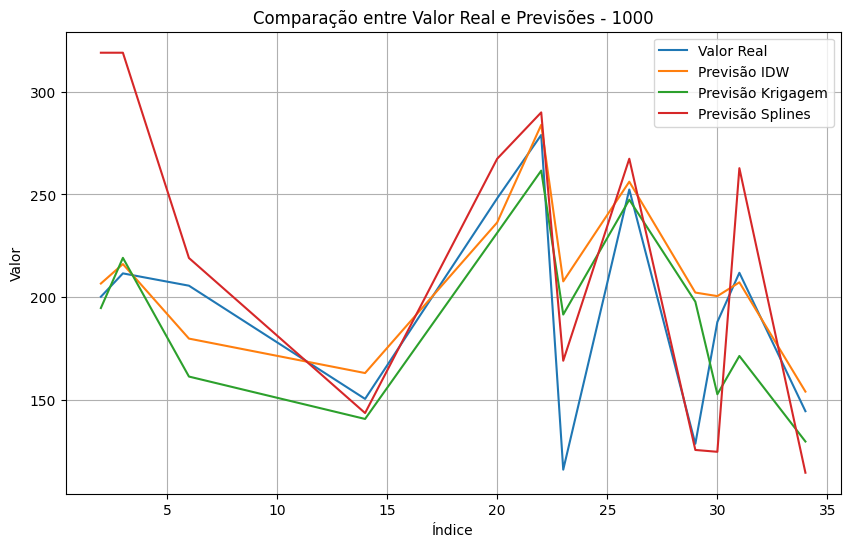

Krigagem
    MAE: 25.620226070055214
    MSE: 1449.2925153811364
    RMSE: 38.06957466772037
    MAPE: 15.281361200646254


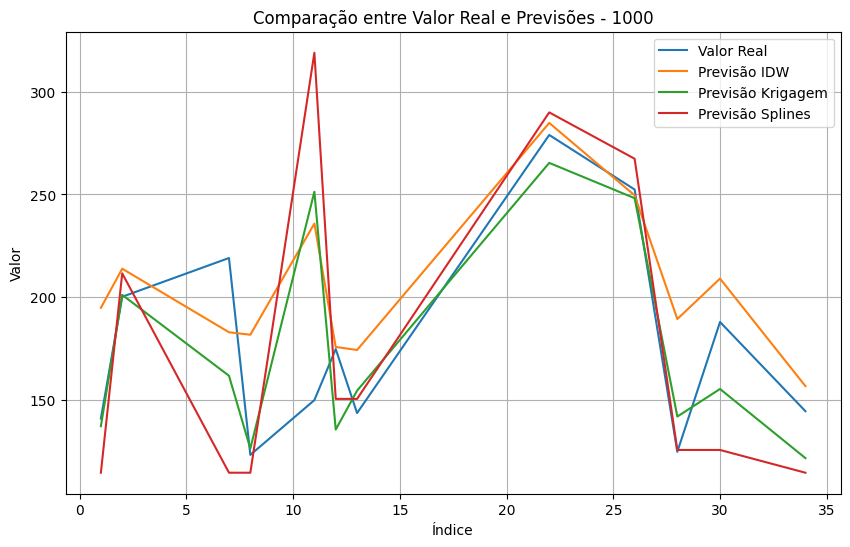

Splines
    MAE: 16.716666666666665
    MSE: 516.8883333333333
    RMSE: 22.73517832200428
    MAPE: 10.916039077769241


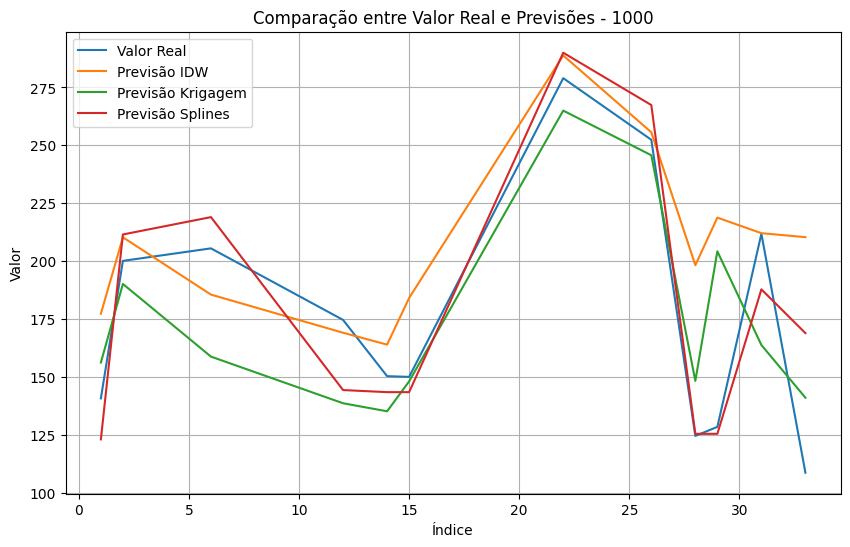

In [ ]:
import matplotlib.pyplot as plt

for metodo, previsao_coluna in [('IDW', 'previsao_IDW'), ('Krigagem', 'previsao_Krigagem'), ('Splines', 'previsao_Splines')]:
        print(metodo)
        mae, mse, rmse, mape = calcular_metricas(best_comba[metodo]['Total'].values, best_comba[metodo][previsao_coluna].values)
        print(f'    MAE: {mae}')
        print(f'    MSE: {mse}')
        print(f'    RMSE: {rmse}')
        print(f'    MAPE: {mape}')

        best_comba[metodo] = best_comba[metodo].sort_index()

        # Extrai os dados relevantes do DataFrame
        value = best_comba[metodo]['Total']
        previsao_IDW = best_comba[metodo]['previsao_IDW']
        previsao_Krigagem = best_comba[metodo]['previsao_Krigagem']
        previsao_Splines = best_comba[metodo]['previsao_Splines']


        # Cria o gráfico de linha
        plt.figure(figsize=(10, 6))
        plt.plot(value, label='Valor Real')
        plt.plot(previsao_IDW, label='Previsão IDW')
        plt.plot(previsao_Krigagem, label='Previsão Krigagem')
        plt.plot(previsao_Splines, label='Previsão Splines')
        plt.xlabel('Índice')
        plt.ylabel('Valor')
        plt.title('Comparação entre Valor Real e Previsões - 1000')
        plt.legend()
        plt.grid(True)
        plt.show()


IDW
    MAE: 22.52039822598378
    MSE: 973.0925428375084
    RMSE: 31.194431279276568
    MAPE: 11.923812790594129


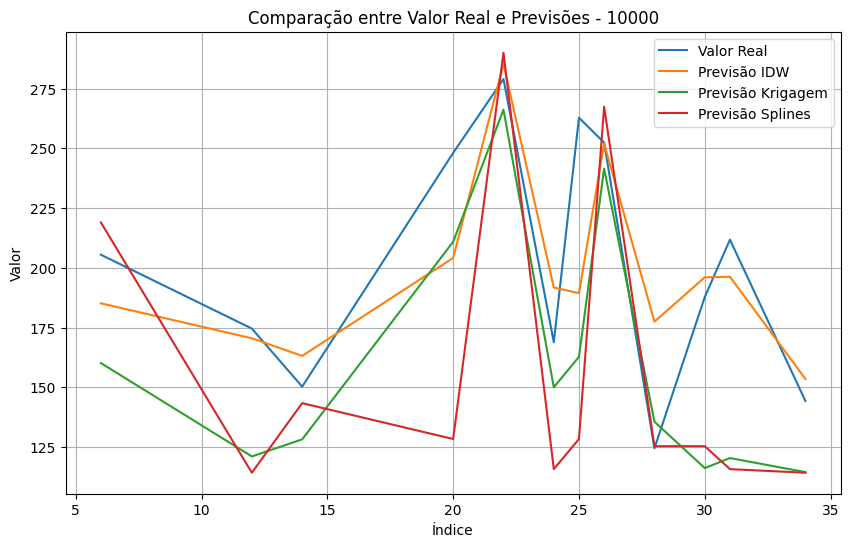

Krigagem
    MAE: 33.80020120854589
    MSE: 3746.792403892221
    RMSE: 61.211048054188886
    MAPE: 13.350971507833778


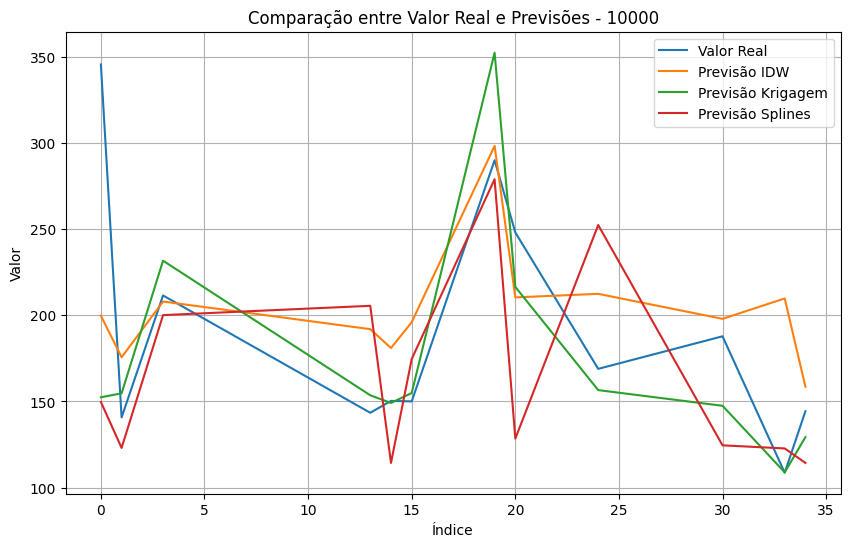

Splines
    MAE: 15.508333333333335
    MSE: 703.3758333333334
    RMSE: 26.52123363143829
    MAPE: 9.348829232064714


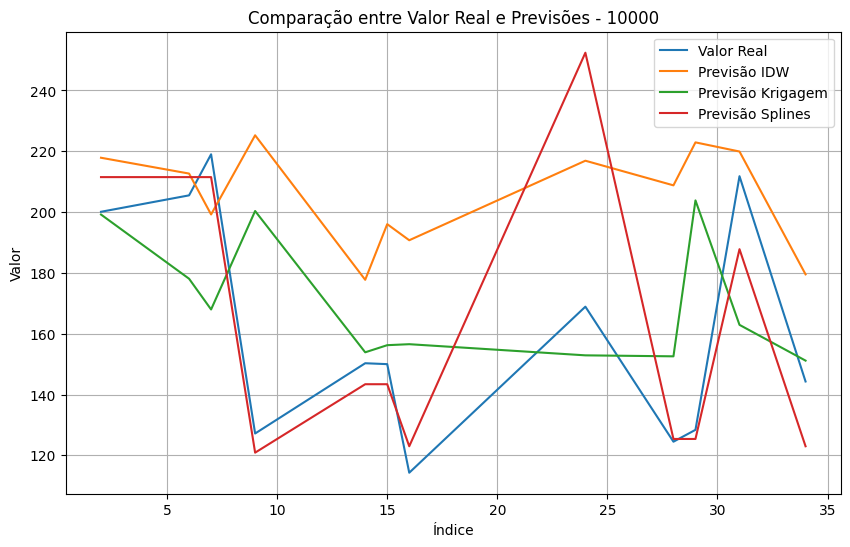

In [ ]:
import matplotlib.pyplot as plt

for metodo, previsao_coluna in [('IDW', 'previsao_IDW'), ('Krigagem', 'previsao_Krigagem'), ('Splines', 'previsao_Splines')]:
        print(metodo)
        mae, mse, rmse, mape = calcular_metricas(best_combb[metodo]['Total'].values, best_combb[metodo][previsao_coluna].values)
        print(f'    MAE: {mae}')
        print(f'    MSE: {mse}')
        print(f'    RMSE: {rmse}')
        print(f'    MAPE: {mape}')

        best_combb[metodo] = best_combb[metodo].sort_index()

        # Extrai os dados relevantes do DataFrame
        value = best_combb[metodo]['Total']
        previsao_IDW = best_combb[metodo]['previsao_IDW']
        previsao_Krigagem = best_combb[metodo]['previsao_Krigagem']
        previsao_Splines = best_combb[metodo]['previsao_Splines']


        # Cria o gráfico de linha
        plt.figure(figsize=(10, 6))
        plt.plot(value, label='Valor Real')
        plt.plot(previsao_IDW, label='Previsão IDW')
        plt.plot(previsao_Krigagem, label='Previsão Krigagem')
        plt.plot(previsao_Splines, label='Previsão Splines')
        plt.xlabel('Índice')
        plt.ylabel('Valor')
        plt.title('Comparação entre Valor Real e Previsões - 10000')
        plt.legend()
        plt.grid(True)
        plt.show()


# Results

In [ ]:
import pandas as pd

# Leia o arquivo CSV para um DataFrame
resultados = pd.read_csv("Resultados_2_1000.csv")

# Função para converter a string do vetor em lista
def convert_to_list(string):
    # Remove os colchetes "[" e "]"
    string = string.strip("[]")
    # Divide os valores pelo separador ","
    values = string.split(", ")
    # Converte os valores para float
    return [float(value) for value in values]

# Aplica a função a cada elemento do DataFrame
resultados = resultados.applymap(convert_to_list)

# Exiba as primeiras linhas do DataFrame para verificar se os dados foram carregados corretamente
print(resultados.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   IDW       1000 non-null   object
 1   Krigagem  1000 non-null   object
 2   Splines   1000 non-null   object
dtypes: object(3)
memory usage: 23.6+ KB
None


In [ ]:
# Exibir resultados
for metodo, metricas in resultados.items():
    print(f'Resultados para {metodo}:')
    for i, (mae, mse, rmse, mape) in enumerate(metricas, start=1):
        print(f'  Execução {i}:')
        print(f'    MAE: {mae}')
        print(f'    MSE: {mse}')
        print(f'    RMSE: {rmse}')
        print(f'    MAPE: {mape}')

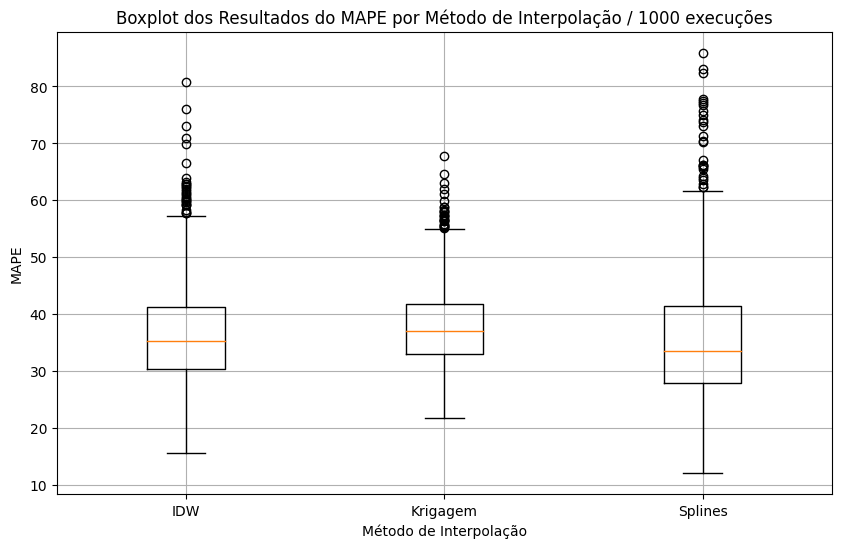

In [ ]:
import matplotlib.pyplot as plt

# Extrair os resultados do MAPE para cada método
mape_idw = [mape for mae, mse, rmse, mape in resultados['IDW']]
mape_krigagem = [mape for mae, mse, rmse, mape in resultados['Krigagem']]
mape_splines = [mape for mae, mse, rmse, mape in resultados['Splines']]

# Gerar o boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([mape_idw, mape_krigagem, mape_splines], labels=['IDW', 'Krigagem', 'Splines'])
plt.title('Boxplot dos Resultados do MAPE por Método de Interpolação / 1000 execuções')
plt.xlabel('Método de Interpolação')
plt.ylabel('MAPE')
plt.grid(True)
plt.show()


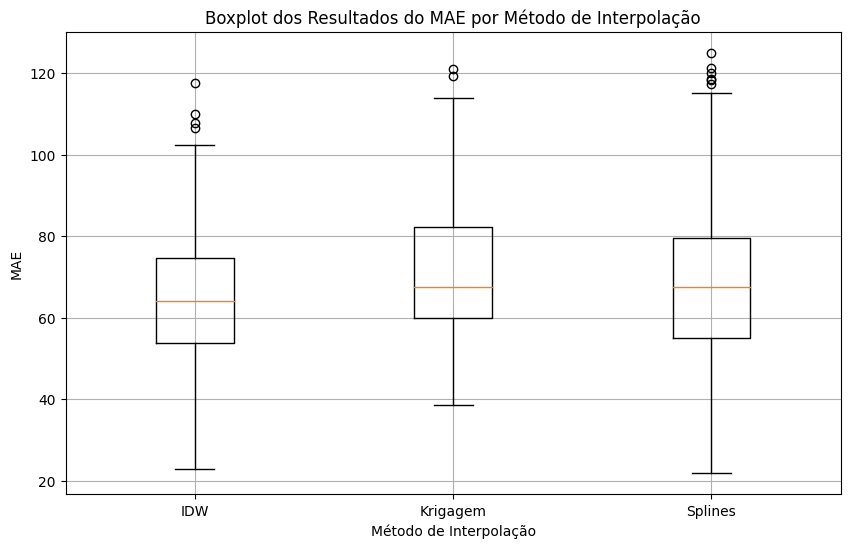

In [ ]:
import matplotlib.pyplot as plt

# Extrair os resultados do MAPE para cada método
mae_idw = [mae for mae, mse, rmse, mape in resultados['IDW']]
mae_krigagem = [mae for mae, mse, rmse, mape in resultados['Krigagem']]
mae_splines = [mae for mae, mse, rmse, mape in resultados['Splines']]

# Gerar o boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([mae_idw, mae_krigagem, mae_splines], labels=['IDW', 'Krigagem', 'Splines'])
plt.title('Boxplot dos Resultados do MAE por Método de Interpolação')
plt.xlabel('Método de Interpolação')
plt.ylabel('MAE')
plt.grid(True)
plt.show()


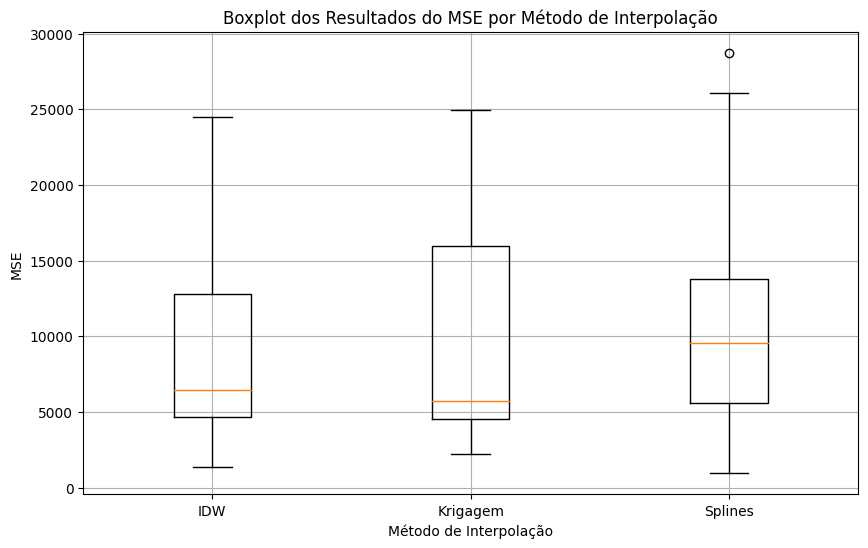

In [ ]:
import matplotlib.pyplot as plt

# Extrair os resultados do MAPE para cada método
mse_idw = [mse for mae, mse, rmse, mape in resultados['IDW']]
mse_krigagem = [mse for mae, mse, rmse, mape in resultados['Krigagem']]
mse_splines = [mse for mae, mse, rmse, mape in resultados['Splines']]

# Gerar o boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([mse_idw, mse_krigagem, mse_splines], labels=['IDW', 'Krigagem', 'Splines'])
plt.title('Boxplot dos Resultados do MSE por Método de Interpolação')
plt.xlabel('Método de Interpolação')
plt.ylabel('MSE')
plt.grid(True)
plt.show()


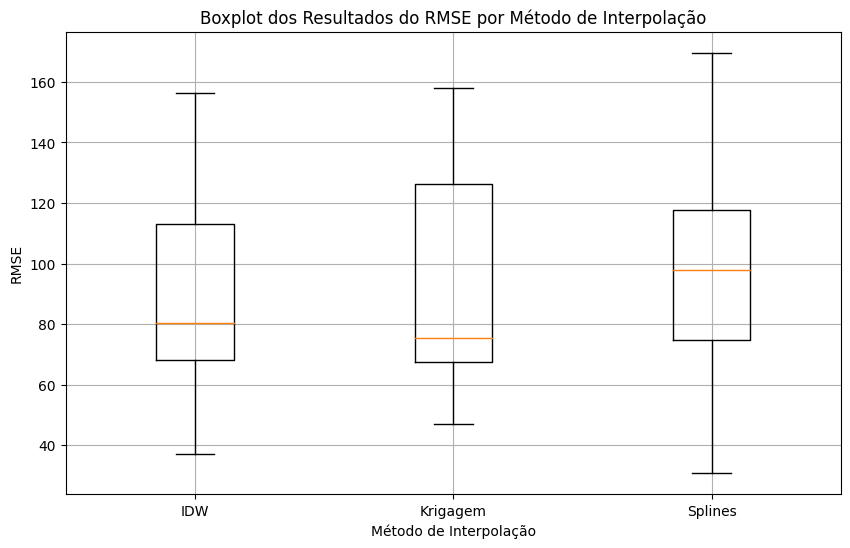

In [ ]:
import matplotlib.pyplot as plt

# Extrair os resultados do MAPE para cada método
rmse_idw = [rmse for mae, mse, rmse, mape in resultados['IDW']]
rmse_krigagem = [rmse for mae, mse, rmse, mape in resultados['Krigagem']]
rmse_splines = [rmse for mae, mse, rmse, mape in resultados['Splines']]

# Gerar o boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([rmse_idw, rmse_krigagem, rmse_splines], labels=['IDW', 'Krigagem', 'Splines'])
plt.title('Boxplot dos Resultados do RMSE por Método de Interpolação')
plt.xlabel('Método de Interpolação')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()


# 10000

In [ ]:

n = 10000
aresultados = {'IDW': [], 'Krigagem': [], 'Splines': []}

# Cálculo do mape
def calculate_mape(y_true, y_pred):
    # Garante que os arrays tenham o mesmo comprimento
    assert len(y_true) == len(y_pred), "Os arrays devem ter o mesmo comprimento"

    # Calcula o MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.abs(y_true))) * 100

    return mape

# Função para calcular as métricas de erro
def calcular_metricas(observados, previstos):
    mae = mean_absolute_error(observados, previstos)
    mse = mean_squared_error(observados, previstos)
    rmse = np.sqrt(mse)
    mape = calculate_mape(observados, previstos)
    return mae, mse, rmse, mape

# Função para encontrar a localização mais próxima com valor maior que zero
def encontrar_localizacao_mais_proxima(row, df_valores_existentes):
    valores_maiores_que_zero = df_valores_existentes[df_valores_existentes['value'] > 0]
    if valores_maiores_que_zero.empty:
        return np.nan
    distancias = cdist([(row['latitude'], row['longitude'])], valores_maiores_que_zero[['latitude', 'longitude']].values)[0]
    indice_mais_proximo = valores_maiores_que_zero.index[np.argmin(distancias)]
    return df_valores_existentes.loc[indice_mais_proximo, 'value']

total_tempo = time.time()
print(n)
for i in range(n):
    tempo_inicial = time.time()
    #print(f'Execução: {i}')

    # Dividir em treino e teste
    novas_loc_aleatorio = novas_loc.sample(frac=1, random_state=i)
    novas_loc_treino = novas_loc_aleatorio[:int(len(novas_loc_aleatorio) * 0.67)].copy()
    novas_loc_teste = novas_loc_aleatorio[int(len(novas_loc_aleatorio) * 0.67):].copy()

    # Realizar as interpolações
    novas_loc_teste['previsao_IDW'] = idw(novas_loc_treino, novas_loc_teste)
    novas_loc_teste['previsao_Krigagem'] = kriging(novas_loc_treino, novas_loc_teste)
    novas_loc_teste['previsao_Splines'] = splines(novas_loc_treino, novas_loc_teste)

    # Adicionar previsões ao DataFrame de teste
    #novas_loc_teste['previsao_IDW'] = novas_loc_teste.apply(encontrar_localizacao_mais_proxima, axis=1, df_valores_existentes=resultado_idw)
    #novas_loc_teste['previsao_Krigagem'] = novas_loc_teste.apply(encontrar_localizacao_mais_proxima, axis=1, df_valores_existentes=resultado_krg)
    #novas_loc_teste['previsao_Splines'] = novas_loc_teste.apply(encontrar_localizacao_mais_proxima, axis=1, df_valores_existentes=resultado_spl)

    # Calcular métricas de erro
    for metodo, previsao_coluna in [('IDW', 'previsao_IDW'), ('Krigagem', 'previsao_Krigagem'), ('Splines', 'previsao_Splines')]:
        mae, mse, rmse, mape = calcular_metricas(novas_loc_teste['Total'].values, novas_loc_teste[previsao_coluna].values)
        aresultados[metodo].append([mae, mse, rmse, mape])
    print(i)
    #print(f'Tempo de execução: {time.time() - tempo_inicial}')

print('-----------------------------------')
print(f'Tempo total: {time.time() - total_tempo}')
resultados_df_2 = pd.DataFrame(aresultados)
resultados_df_2.to_csv("Resultados_2_10000.csv", index=False)

In [ ]:
# Cálculo do mape
def calculate_mape(y_true, y_pred):
    # Garante que os arrays tenham o mesmo comprimento
    assert len(y_true) == len(y_pred), "Os arrays devem ter o mesmo comprimento"

    # Calcula o MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.abs(y_true))) * 100

    return mape

# Função para calcular as métricas de erro
def calcular_metricas(observados, previstos):
    mae = mean_absolute_error(observados, previstos)
    mse = mean_squared_error(observados, previstos)
    rmse = np.sqrt(mse)
    mape = calculate_mape(observados, previstos)
    return mae, mse, rmse, mape

In [ ]:
import pandas as pd

# Leia o arquivo CSV para um DataFrame
resultados = pd.read_csv("Resultados_2_10000.csv")
#resultados = resultados_df_2
# Função para converter a string do vetor em lista
def convert_to_list(string):
    # Remove os colchetes "[" e "]"
    string = string.strip("[]")
    # Divide os valores pelo separador ","
    values = string.split(", ")
    # Converte os valores para float
    return [float(value) for value in values]

# Aplica a função a cada elemento do DataFrame
aresultados = resultados.applymap(convert_to_list)

# Exiba as primeiras linhas do DataFrame para verificar se os dados foram carregados corretamente
print(resultados.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   IDW       10000 non-null  object
 1   Krigagem  10000 non-null  object
 2   Splines   10000 non-null  object
dtypes: object(3)
memory usage: 234.5+ KB
None


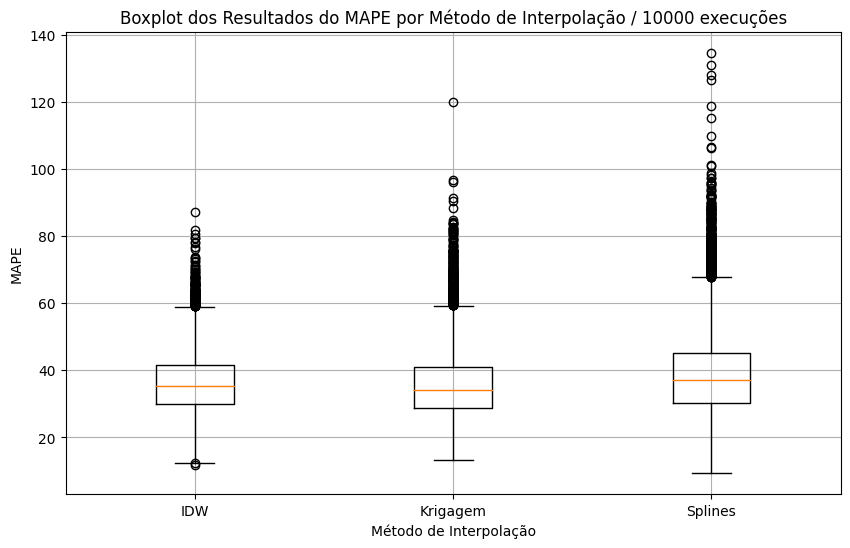

In [ ]:
import matplotlib.pyplot as plt

# Extrair os resultados do MAPE para cada método
mape_idw = [mape for mae, mse, rmse, mape in aresultados['IDW']]
mape_krigagem = [mape for mae, mse, rmse, mape in aresultados['Krigagem']]
mape_splines = [mape for mae, mse, rmse, mape in aresultados['Splines']]

# Gerar o boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([mape_idw, mape_krigagem, mape_splines], labels=['IDW', 'Krigagem', 'Splines'])
plt.title('Boxplot dos Resultados do MAPE por Método de Interpolação / 10000 execuções')
plt.xlabel('Método de Interpolação')
plt.ylabel('MAPE')
plt.grid(True)
plt.show()


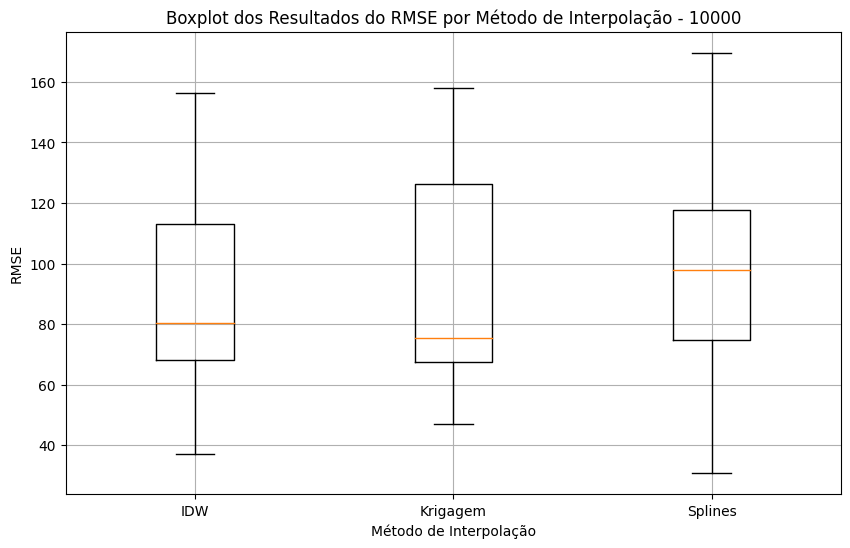

In [ ]:
import matplotlib.pyplot as plt

# Extrair os resultados do MAPE para cada método
mape_idw = [rmse for mae, mse, rmse, mape in aresultados['IDW']]
mape_krigagem = [rmse for mae, mse, rmse, mape in aresultados['Krigagem']]
mape_splines = [rmse for mae, mse, rmse, mape in aresultados['Splines']]

# Gerar o boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([mape_idw, mape_krigagem, mape_splines], labels=['IDW', 'Krigagem', 'Splines'])
plt.title('Boxplot dos Resultados do RMSE por Método de Interpolação - 10000')
plt.xlabel('Método de Interpolação')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()


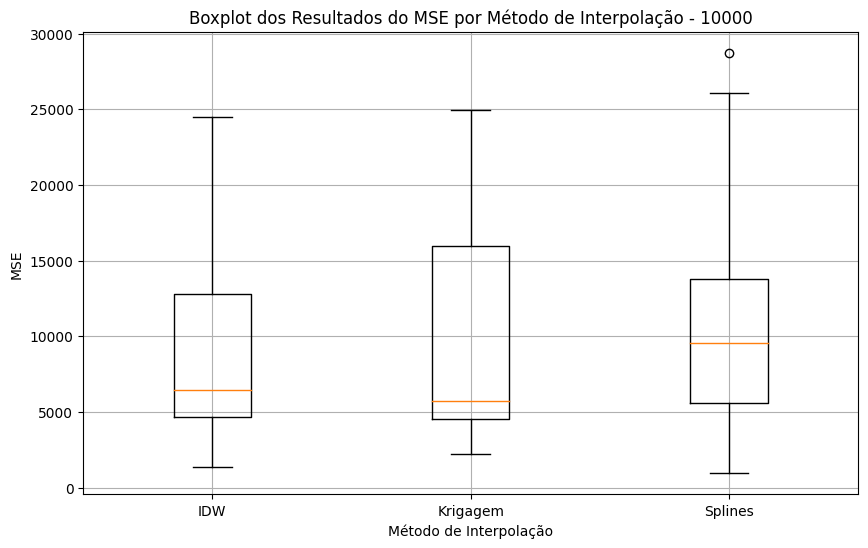

In [ ]:
import matplotlib.pyplot as plt

# Extrair os resultados do MAPE para cada método
mape_idw = [mse for mae, mse, rmse, mape in aresultados['IDW']]
mape_krigagem = [mse for mae, mse, rmse, mape in aresultados['Krigagem']]
mape_splines = [mse for mae, mse, rmse, mape in aresultados['Splines']]

# Gerar o boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([mape_idw, mape_krigagem, mape_splines], labels=['IDW', 'Krigagem', 'Splines'])
plt.title('Boxplot dos Resultados do MSE por Método de Interpolação - 10000')
plt.xlabel('Método de Interpolação')
plt.ylabel('MSE')
plt.grid(True)
plt.show()


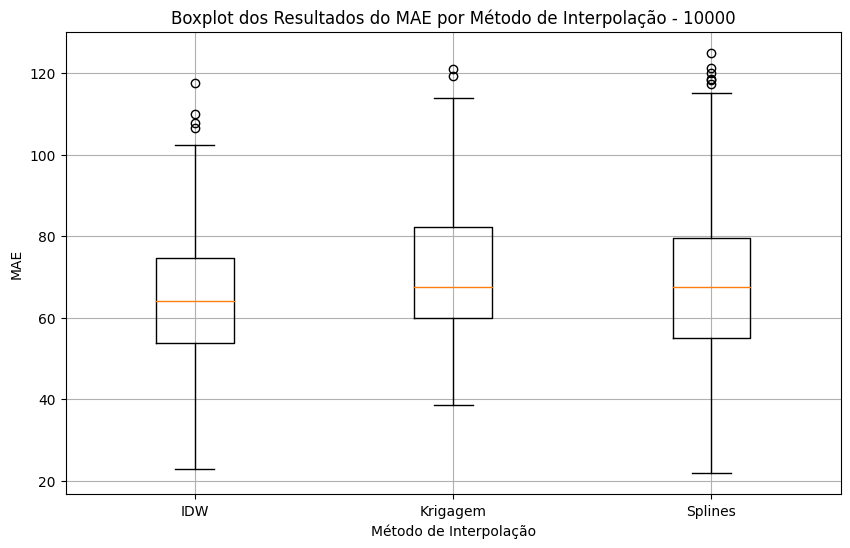

In [ ]:
import matplotlib.pyplot as plt

# Extrair os resultados do MAPE para cada método
mape_idw = [mae for mae, mse, rmse, mape in aresultados['IDW']]
mape_krigagem = [mae for mae, mse, rmse, mape in aresultados['Krigagem']]
mape_splines = [mae for mae, mse, rmse, mape in aresultados['Splines']]

# Gerar o boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([mape_idw, mape_krigagem, mape_splines], labels=['IDW', 'Krigagem', 'Splines'])
plt.title('Boxplot dos Resultados do MAE por Método de Interpolação - 10000')
plt.xlabel('Método de Interpolação')
plt.ylabel('MAE')
plt.grid(True)
plt.show()


# nada

In [ ]:
dataframe = pd.read_csv("Resultados_2_10000.csv")

# Visualizando o DataFrame
dataframe

,IDW,Krigagem,Splines
0,"[82.29921695195665, 14421.571996174005, 120.08...","[90.28969662138849, 18462.762439218965, 135.87...","[78.64292240495112, 14360.360693914232, 119.83..."
1,"[66.35360392094363, 5985.840141886508, 77.3682...","[71.42149293264673, 6144.426369917383, 78.3863...","[58.53418464205609, 8007.9456584271875, 89.487..."
2,"[69.85535170984849, 13090.308571612572, 114.41...","[83.218316060249, 16470.021647183017, 128.3355...","[72.0778928563619, 13165.626767825908, 114.741..."
3,"[86.65367113400713, 14635.799983989265, 120.97...","[92.94044690105709, 18122.86827639166, 134.621...","[93.44109535721174, 16319.725689867146, 127.74..."
4,"[63.047852118499804, 5367.2170999449545, 73.26...","[63.28276718642653, 4747.2951012370695, 68.900...","[63.55459210205746, 5756.593159956047, 75.8722..."
...,...,...,...
995,"[44.90623664008106, 3386.1536831828103, 58.190...","[58.62361365488413, 4545.003956074465, 67.4166...","[46.62757816672717, 5288.796038493172, 72.7241..."
996,"[57.030973062338326, 4350.672381152885, 65.959...","[73.472409727107, 5761.210422230727, 75.902637...","[48.060094579143936, 3923.1702927245988, 62.63..."
997,"[66.60810793501204, 6719.937081721592, 81.9752...","[73.80676760711894, 6237.065053416271, 78.9750...","[58.013951300169765, 6428.222120782408, 80.176..."
998,"[66.72733745331496, 6114.117844766998, 78.1928...","[67.5518828031985, 5997.610388013032, 77.44424...","[58.642659883135735, 4775.976197038156, 69.108..."


# All Combs

In [ ]:
import pandas as pd
from itertools import combinations

df = novas_loc.loc[:, ["nome", "latitude", "longitude", "Total"]]

resultados_30_5 = {'IDW': [], 'Krigagem': [], 'Splines': []}

# Gerar todas as combinações possíveis de índices
indices = list(df.index)
combs_30_5 = list(combinations(indices, 30))
print(len(combs_30_5))

324632


In [11]:
# Cálculo do mape
def calculate_mape(y_true, y_pred):
    # Garante que os arrays tenham o mesmo comprimento
    assert len(y_true) == len(y_pred), "Os arrays devem ter o mesmo comprimento"

    # Calcula o MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.abs(y_true))) * 100

    return mape

# Função para calcular as métricas de erro
def calcular_metricas(observados, previstos):
    mae = mean_absolute_error(observados, previstos)
    mse = mean_squared_error(observados, previstos)
    rmse = np.sqrt(mse)
    mape = calculate_mape(observados, previstos)
    return mae, mse, rmse, mape


In [12]:
def idw(treino, teste):
  # Calcula a matriz de distâncias entre as localizações interpoladas e as existentes
  delta_lat = teste['latitude'].values[:, np.newaxis] - treino['latitude'].values
  delta_lon = teste['longitude'].values[:, np.newaxis] - treino['longitude'].values
  distances = np.sqrt(delta_lat**2 + delta_lon**2)

  # Calcula o inverso das distâncias elevadas a 2
  inverted_distances = (distances)**2
  inverted_distances = 1 / inverted_distances

  # Normaliza os pesos para que a soma seja igual a 1
  weights_sum = np.sum(inverted_distances, axis=1, keepdims=True)
  normalized_weights = inverted_distances / weights_sum

  # Calcula os novos valores usando operações vetorizadas
  values = np.sum(normalized_weights * treino['Total'].values, axis=1)

  result_IDW = pd.DataFrame({
        'latitude': teste['latitude'],
        'longitude': teste['longitude'],
        'value': values
  })

  return result_IDW['value']

def kriging(treino, teste):
    # Configuração do modelo de variograma
    variogram_model = 'exponential'
    sill = 100  # Ajuste conforme necessário
    range_ = 0.5  # Ajuste conforme necessário
    nugget = 0.0  # Ajuste conforme necessário

    # Configuração do modelo de krigagem
    model = OrdinaryKriging(
        treino['longitude'],
        treino['latitude'],
        treino['Total'],
        variogram_model=variogram_model,
        variogram_parameters={'sill': sill, 'range': range_, 'nugget': nugget},
        verbose=False
    )

    # Realiza a krigagem nas novas localizações do dataframe de teste
    kriged, _ = model.execute('points', teste['longitude'], teste['latitude'])

    # Cria um DataFrame com os resultados da krigagem
    result_krg = pd.DataFrame({
        'latitude': teste['latitude'],
        'longitude': teste['longitude'],
        'value': kriged.flatten()
    })

    return result_krg['value']

def splines(treino, teste):
    # Extrai as colunas necessárias do dataframe de treino
    points = treino[['latitude', 'longitude']].values
    values = treino['Total'].values

    # Extrai as colunas necessárias do dataframe de teste
    grid_x, grid_y = teste['latitude'].values, teste['longitude'].values

    # Realiza a interpolação por splines
    interpolated_values = griddata(points, values, (grid_x, grid_y), method='cubic')

    # Se houver NaN após a interpolação cúbica, preenche com o valor mais próximo
    if np.any(np.isnan(interpolated_values)):
        interpolated_values = griddata(points, values, (grid_x, grid_y), method='nearest')

    return interpolated_values

In [ ]:
# Função para dividir o dataframe com base nos índices
def split_dataframe(df, train_indices, test_indices):
    train_df = df.loc[train_indices]
    test_df = df.loc[test_indices]
    return train_df, test_df

best_mape = {'IDW': 99999, 'Krigagem': 99999, 'Splines': 99999}
best_comb = {'IDW': [], 'Krigagem': [], 'Splines': []}


i = 0
# Separar o dataframe em 8 para treino e 1 para teste
for comb in combs_30_5:
    train_indices = np.array(comb)
    test_indices = list(set(indices) - set(comb))
    train_df, test_df = split_dataframe(df, train_indices, test_indices)

    test_df['previsao_IDW'] = idw(train_df,test_df)
    test_df['previsao_Krigagem'] = kriging(train_df,test_df)
    test_df['previsao_Splines'] = splines(train_df,test_df)

    # Calcular métricas de erro
    for metodo, previsao_coluna in [('IDW', 'previsao_IDW'), ('Krigagem', 'previsao_Krigagem'), ('Splines', 'previsao_Splines')]:
        mae, mse, rmse, mape = calcular_metricas(test_df['Total'].values, test_df[previsao_coluna].values)
        resultados_30_5[metodo].append([mae, mse, rmse, mape])
        if best_mape[metodo] > mape:
            best_mape[metodo] = mape
            best_comb[metodo] = comb
    print(i)
    i = i+1




A saída de streaming foi truncada nas últimas 5000 linhas.
319632
319633
319634
319635
319636
319637
319638
319639
319640
319641
319642
319643
319644
319645
319646
319647
319648
319649
319650
319651
319652
319653
319654
319655
319656
319657
319658
319659
319660
319661
319662
319663
319664
319665
319666
319667
319668
319669
319670
319671
319672
319673
319674
319675
319676
319677
319678
319679
319680
319681
319682
319683
319684
319685
319686
319687
319688
319689
319690
319691
319692
319693
319694
319695
319696
319697
319698
319699
319700
319701
319702
319703
319704
319705
319706
319707
319708
319709
319710
319711
319712
319713
319714
319715
319716
319717
319718
319719
319720
319721
319722
319723
319724
319725
319726
319727
319728
319729
319730
319731
319732
319733
319734
319735
319736
319737
319738
319739
319740
319741
319742
319743
319744
319745
319746
319747
319748
319749
319750
319751
319752
319753
319754
319755
319756
319757
319758
319759
319760
319761
319762
319763
319764
319765
319

In [ ]:
print(resultados_30_5.keys())
print(len(resultados_30_5['IDW']))
print(len(resultados_30_5['Krigagem']))
print(len(resultados_30_5['Splines']))

print(best_comb)
print(best_mape)


#Best Result:
#(0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 27, 28, 29, 31, 32, 33, 34) IDW
#(0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34) Krigagem
#(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 30, 31, 32, 33, 34) Splines

In [ ]:
auxsave = pd.DataFrame(resultados_30_5)

auxsave.to_csv('resultado_peuza.csv', index=False)

In [ ]:
%pip install pyexcel_ods

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 746.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for odfpy: filename=odfpy-1.4.1-py2.py3-none-any.whl size=160672 sha256=921aedbf006309c18ce0bfc56034815cb6a22a171f05305fd39084e52beacd11
  Stored in directory: /root/.cache/pip/wheels/c8/2e/95/90d94fe33903786937f3b8c33dd88807f792359c6424b40469
Successfully built odfpy


# Resultados de novo

In [ ]:
import pandas as pd
import pyexcel_ods

# Leia o arquivo ODS para um DataFrame
data = pyexcel_ods.get_data("resultado_30_5.ods")

# Converte os dados para um DataFrame pandas
df = pd.DataFrame(data['resultado_30_5'])

# Extrai os títulos das colunas
column_titles = df.iloc[0]

# Remove os títulos das colunas dos dados
data_values = df.iloc[1:].reset_index(drop=True)  # reset_index() para redefinir o índice e drop=True para descartar o índice anterior

# Converte os dados para um DataFrame pandas e define os títulos das colunas
df = pd.DataFrame(data_values.values, columns=column_titles)

# Função para converter a string do vetor em lista
def convert_to_list(string):
    # Remove os colchetes "[" e "]"
    string = string.strip("[]")
    # Divide os valores pelo separador ","
    values = string.split(", ")
    # Converte os valores para float
    return [float(value) for value in values]

# Aplica a função a cada elemento do DataFrame
df = df.applymap(convert_to_list)

# Exiba as primeiras linhas do DataFrame para verificar se os dados foram carregados corretamente
len(df)
print(df.head())

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [ ]:
df

,IDW,Krigagem,Splines
0,"[57.544512831675455, 6567.99031271009, 81.0431...","[69.17734659261998, 6164.847482611162, 78.5165...","[81.20000000000002, 8443.988000000003, 91.8911..."
1,"[73.14337490554726, 8450.282215936288, 91.9254...","[68.4431778466593, 6145.8899084824925, 78.3957...","[54.74000000000001, 5916.410000000002, 76.9182..."
2,"[77.68025617267172, 8599.123606481844, 92.7314...","[66.92586870070633, 6057.68221222156, 77.83111...","[62.60000000000001, 6602.588000000002, 81.2563..."
3,"[45.98937079532682, 3844.523919911187, 62.0042...","[46.693898903339345, 2660.4940799483124, 51.57...","[50.52, 3553.5960000000014, 59.61204576258058,..."
4,"[52.97645338918778, 5476.388602369805, 74.0026...","[64.18311838930671, 5144.721639823026, 71.7267...","[69.74000000000001, 7718.570000000004, 87.8553..."
...,...,...,...
324627,"[49.80676233355894, 5283.781088428552, 72.6896...","[58.96646319690562, 8088.083798208955, 89.9337...","[104.42000000000003, 14140.030000000004, 118.9..."
324628,"[45.12535111659681, 5056.984082818503, 71.1124...","[52.65740796758357, 7913.8072047790965, 88.959...","[108.98000000000002, 15078.190000000006, 122.7..."
324629,"[41.90488696163639, 4764.805359370935, 69.0275...","[53.32322467304575, 7880.902358469136, 88.7744...","[90.74000000000001, 12922.222000000005, 113.67..."
324630,"[79.0561809729949, 10481.924930476089, 102.381...","[99.59037878381432, 16051.651374062367, 126.69...","[93.64000000000001, 14739.020000000004, 121.40..."


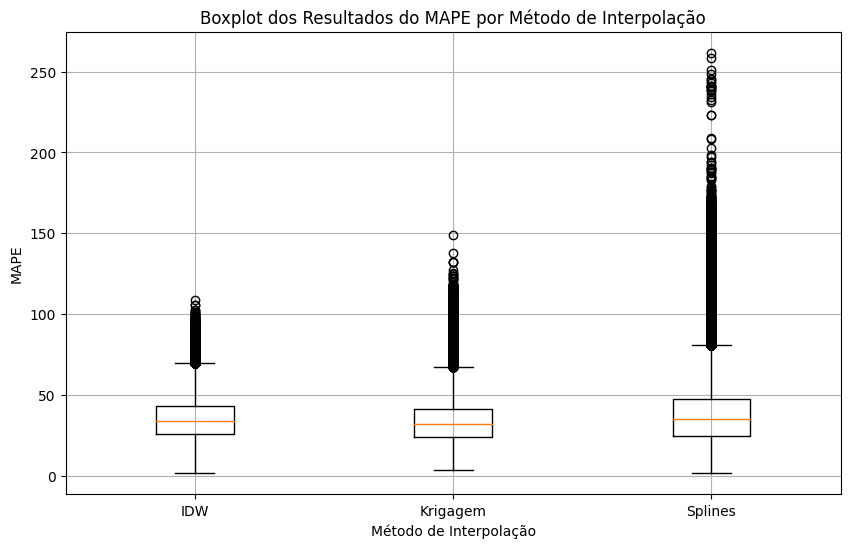

In [ ]:
import matplotlib.pyplot as plt

resultados_30_5 = df

# Extrair os resultados do MAPE para cada método
mape_idw = [mape for mae, mse, rmse, mape in resultados_30_5['IDW']]
mape_krigagem = [mape for mae, mse, rmse, mape in resultados_30_5['Krigagem']]
mape_splines = [mape for mae, mse, rmse, mape in resultados_30_5['Splines']]


# Gerar o boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([mape_idw, mape_krigagem, mape_splines], labels=['IDW', 'Krigagem', 'Splines'])
plt.title('Boxplot dos Resultados do MAPE por Método de Interpolação')
plt.xlabel('Método de Interpolação')
plt.ylabel('MAPE')
plt.grid(True)
plt.show()


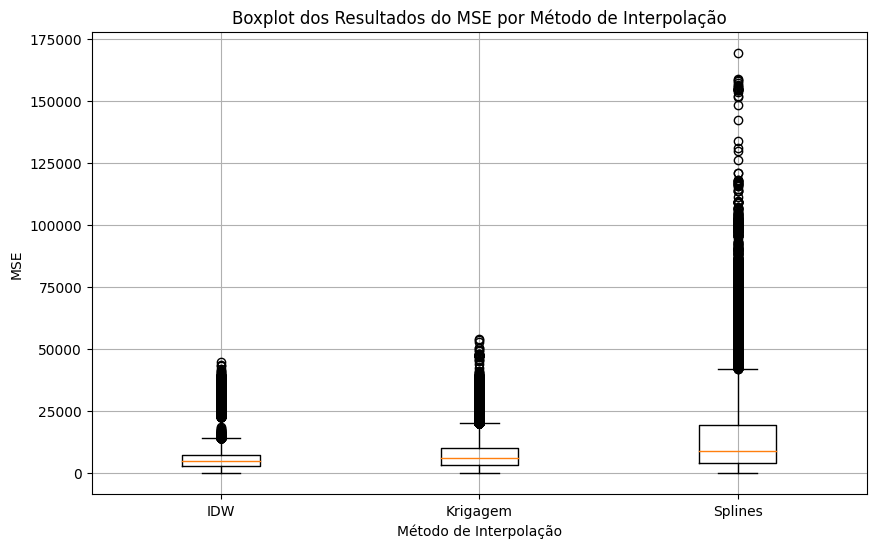

In [ ]:
# Extrair os resultados do MAPE para cada método
mape_idw = [mse for mae, mse, rmse, mape in resultados_30_5['IDW']]
mape_krigagem = [mse for mae, mse, rmse, mape in resultados_30_5['Krigagem']]
mape_splines = [mse for mae, mse, rmse, mape in resultados_30_5['Splines']]


# Gerar o boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([mape_idw, mape_krigagem, mape_splines], labels=['IDW', 'Krigagem', 'Splines'])
plt.title('Boxplot dos Resultados do MSE por Método de Interpolação')
plt.xlabel('Método de Interpolação')
plt.ylabel('MSE')
plt.grid(True)
plt.show()

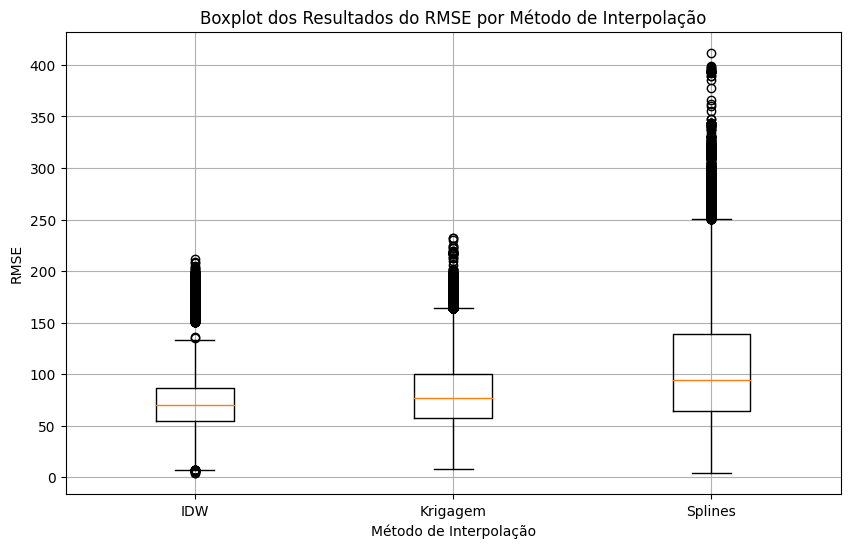

In [ ]:
# Extrair os resultados do MAPE para cada método
mape_idw = [rmse for mae, mse, rmse, mape in resultados_30_5['IDW']]
mape_krigagem = [rmse for mae, mse, rmse, mape in resultados_30_5['Krigagem']]
mape_splines = [rmse for mae, mse, rmse, mape in resultados_30_5['Splines']]


# Gerar o boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([mape_idw, mape_krigagem, mape_splines], labels=['IDW', 'Krigagem', 'Splines'])
plt.title('Boxplot dos Resultados do RMSE por Método de Interpolação')
plt.xlabel('Método de Interpolação')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

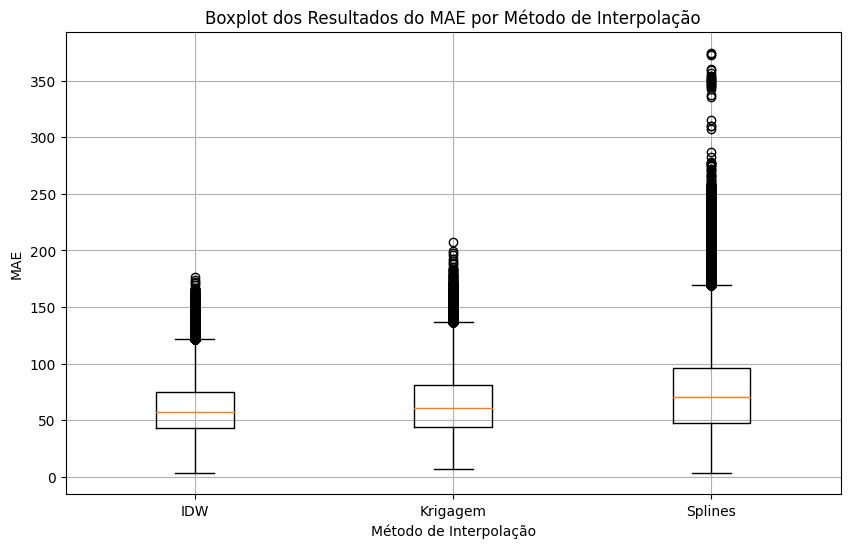

In [ ]:
# Extrair os resultados do MAPE para cada método
mape_idw = [mae for mae, mse, rmse, mape in resultados_30_5['IDW']]
mape_krigagem = [mae for mae, mse, rmse, mape in resultados_30_5['Krigagem']]
mape_splines = [mae for mae, mse, rmse, mape in resultados_30_5['Splines']]


# Gerar o boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([mape_idw, mape_krigagem, mape_splines], labels=['IDW', 'Krigagem', 'Splines'])
plt.title('Boxplot dos Resultados do MAE por Método de Interpolação')
plt.xlabel('Método de Interpolação')
plt.ylabel('MAE')
plt.grid(True)
plt.show()

In [ ]:
best_comb =  {
     'IDW': [],
     'Krigagem': [],
     'Splines': [],
 }

# Uhum

In [ ]:
# IDW
indices_novos = [0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 27, 28, 29, 31, 32, 33, 34]
best_df_train = novas_loc.iloc[indices_novos]
best_df_test = novas_loc.drop(indices_novos)

best_df_test['previsao_IDW'] = idw(best_df_train,best_df_test)
best_df_test['previsao_Krigagem'] = kriging(best_df_train,best_df_test)
best_df_test['previsao_Splines'] = splines(best_df_train,best_df_test)

best_comb['IDW'] = best_df_test

# Krigagem
indices_novos = [0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34]
best_df_train = novas_loc.iloc[indices_novos]
best_df_test = novas_loc.drop(indices_novos)

best_df_test['previsao_IDW'] = idw(best_df_train,best_df_test)
best_df_test['previsao_Krigagem'] = kriging(best_df_train,best_df_test)
best_df_test['previsao_Splines'] = splines(best_df_train,best_df_test)

best_comb['Krigagem'] = best_df_test

#Splines
indices_novos = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 30, 31, 32, 33, 34]
best_df_train = novas_loc.iloc[indices_novos]
best_df_test = novas_loc.drop(indices_novos)

best_df_test['previsao_IDW'] = idw(best_df_train,best_df_test)
best_df_test['previsao_Krigagem'] = kriging(best_df_train,best_df_test)
best_df_test['previsao_Splines'] = splines(best_df_train,best_df_test)

best_comb['Splines'] = best_df_test

IDW
    MAE: 3.6097562627985327
    MSE: 16.523410019027374
    RMSE: 4.064899755101886
    MAPE: 1.614507472089264


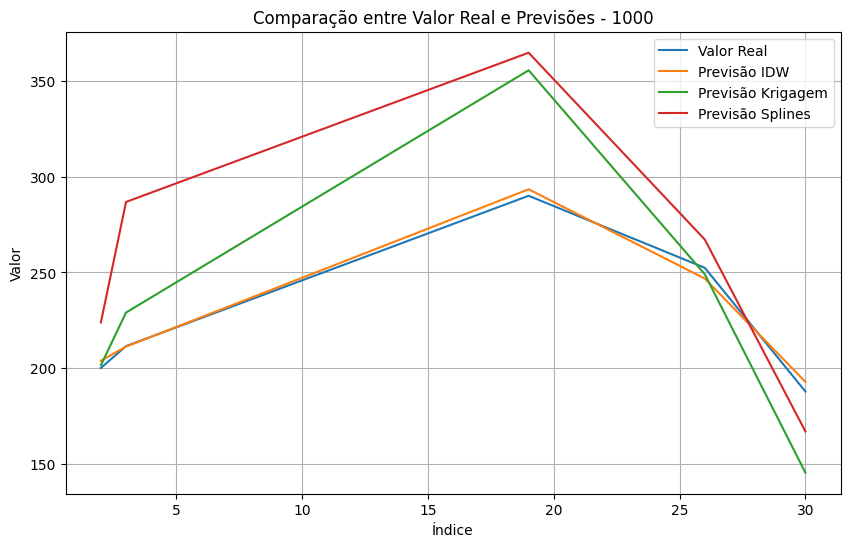

Krigagem
    MAE: 6.430890370289006
    MSE: 81.32762298597368
    RMSE: 9.018182909321238
    MAPE: 3.4184230619932054


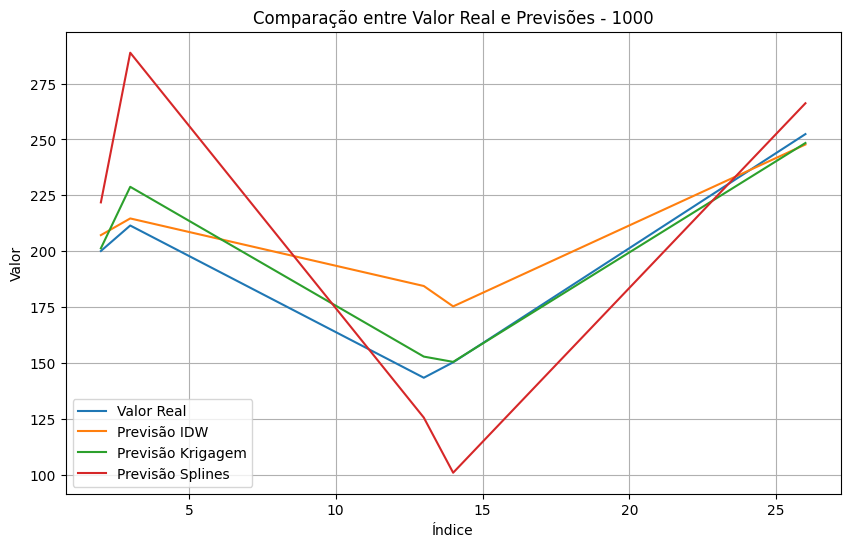

Splines
    MAE: 3.139999999999998
    MSE: 15.733999999999957
    RMSE: 3.9666106438620816
    MAPE: 1.9642872326142515


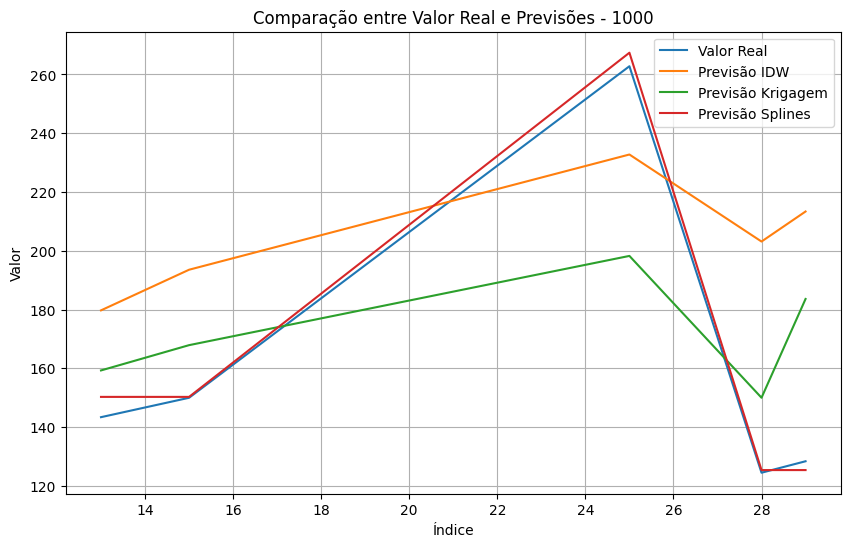

In [ ]:
import matplotlib.pyplot as plt

for metodo, previsao_coluna in [('IDW', 'previsao_IDW'), ('Krigagem', 'previsao_Krigagem'), ('Splines', 'previsao_Splines')]:
        print(metodo)
        mae, mse, rmse, mape = calcular_metricas(best_comb[metodo]['Total'].values, best_comb[metodo][previsao_coluna].values)
        print(f'    MAE: {mae}')
        print(f'    MSE: {mse}')
        print(f'    RMSE: {rmse}')
        print(f'    MAPE: {mape}')

        best_comb[metodo] = best_comb[metodo].sort_index()

        # Extrai os dados relevantes do DataFrame
        value = best_comb[metodo]['Total']
        previsao_IDW = best_comb[metodo]['previsao_IDW']
        previsao_Krigagem = best_comb[metodo]['previsao_Krigagem']
        previsao_Splines = best_comb[metodo]['previsao_Splines']


        # Cria o gráfico de linha
        plt.figure(figsize=(10, 6))
        plt.plot(value, label='Valor Real')
        plt.plot(previsao_IDW, label='Previsão IDW')
        plt.plot(previsao_Krigagem, label='Previsão Krigagem')
        plt.plot(previsao_Splines, label='Previsão Splines')
        plt.xlabel('Índice')
        plt.ylabel('Valor')
        plt.title('Comparação entre Valor Real e Previsões - 1000')
        plt.legend()
        plt.grid(True)
        plt.show()


In [ ]:
best_comb['IDW']['Total']

2     200.1
3     211.5
19    290.0
26    252.4
30    187.8
Name: Total, dtype: float64

In [ ]:
import folium

# Cria um mapa com a localização de São José dos Campos
mapa = folium.Map(location=[-23.1791, -45.8872], zoom_start=10)


# Adiciona um círculo vermelho para cada localização, com o tamanho proporcional à média de valores
for lat, lon, val in zip(best_comb['IDW']['latitude'], best_comb['IDW']['longitude'], best_comb['IDW']['Total']):
  folium.CircleMarker(location=[lat, lon], radius=val/20, color='blue', fill=True).add_to(mapa)

# Adiciona um círculo vermelho para cada localização, com o tamanho proporcional à média de valores
for lat, lon, val in zip(best_comb['IDW']['latitude'], best_comb['IDW']['longitude'], best_comb['IDW']['previsao_IDW']):
  folium.CircleMarker(location=[lat, lon], radius=val/20, color='Yellow', fill=True).add_to(mapa)


# Mostra o mapa
mapa


# Data view

In [10]:
import pandas as pd
!pip install odfpy

# Leia o arquivo ODS para um DataFrame
resultados = pd.read_excel("resultado_30_5.ods", engine='odf')

# Função para converter a string do vetor em lista
def convert_to_list(string):
    # Remove os colchetes "[" e "]"
    string = string.strip("[]")
    # Divide os valores pelo separador ","
    values = string.split(", ")
    # Converte os valores para float
    return [float(value) for value in values]

# Aplica a função a cada elemento do DataFrame
resultados = resultados.applymap(convert_to_list)

# Exiba as primeiras linhas do DataFrame para verificar se os dados foram carregados corretamente
print(resultados.head())


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for odfpy: filename=odfpy-1.4.1-py2.py3-none-any.whl size=160672 sha256=f5213b230aedf6fdd549d6d8f8bfb62257767bc47d878719df0f78b30d0fbf1e
  Stored in directory: /root/.cache/pip/wheels/c8/2e/95/90d94fe33903786937f3b8c33dd88807f792359c6424b40469
Successfully built odfpy
                                                 IDW  \
0  [57.544512831675455, 6567.99031271009, 81.0431...   
1  [73.14337490554726, 8450.282215936288, 91.9254...   
2  [77.68025617267172, 8599.123606481844, 92.7314...   
3  [45.98937079532682, 3844.523919911187, 62.0042...   
4  [52.97645338918778, 5476.388602369805, 74.0026...   

                                            Krigagem  \
0  [69.17734659261998, 6164.847482611162, 78.5165...   
1  [68.4431778466593, 6145.8899084824925, 78.3957...   
2  [66.92586870070633, 6057.68221222156, 77.83111...   
3  [46.693898903339345, 2660.49

In [16]:
resultados['IDW'][0][0]

57.544512831675455

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458431 entries, 0 to 458430
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   IDW       458431 non-null  object
 1   Krigagem  458426 non-null  object
 2   Splines   458413 non-null  object
 3   None      22 non-null      object
 4   None      4 non-null       object
dtypes: object(5)
memory usage: 17.5+ MB


In [17]:
import pandas as pd
import ast

# Função para converter string para lista
def string_to_list(s):
    return ast.literal_eval(s)

# Converter as strings em listas reais
resultados['IDW'] = resultados['IDW']
resultados['Krigagem'] = resultados['Krigagem']
resultados['Splines'] = resultados['Splines']

# Extrair o quarto valor (índice 3) de cada linha para cada coluna
idw_array = [row[3] for row in resultados['IDW']]
krigagem_array = [row[3] for row in resultados['Krigagem']]
splines_array = [row[3] for row in resultados['Splines']]

print("IDW Array:", idw_array)
print("Krigagem Array:", krigagem_array)
print("Splines Array:", splines_array)


IDW Array: 

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



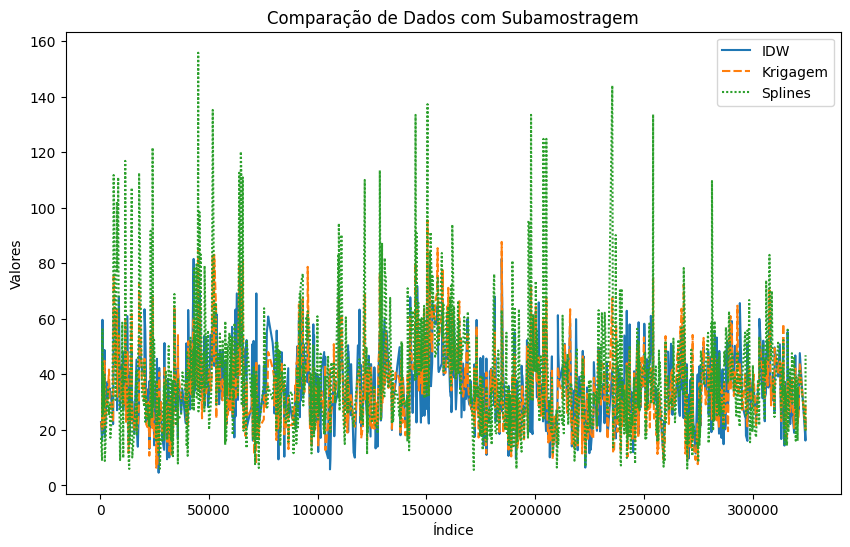

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Criação de um DataFrame
df = pd.DataFrame({
    'IDW': idw_array,
    'Krigagem': krigagem_array,
    'Splines': splines_array
})

# Subamostragem
sample_size = 1000
df_sampled = df.sample(n=sample_size, random_state=42)

# Criação do gráfico
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_sampled)

# Adição de títulos e rótulos
plt.xlabel('Índice')
plt.ylabel('Valores')
plt.title('Comparação de Dados com Subamostragem')

# Mostrar gráfico
plt.show()


In [21]:
# Subamostragem
sample_size = 1000
df_sampled = df.sample(n=sample_size, random_state=42)

# Criação do gráfico
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_sampled.index, y='Data 1', alpha=0.1, data=df_sampled, label='Data 1')
sns.scatterplot(x=df_sampled.index, y='Data 2', alpha=0.1, data=df_sampled, label='Data 2')
sns.scatterplot(x=df_sampled.index, y='Data 3', alpha=0.1, data=df_sampled, label='Data 3')

# Adição de títulos e rótulos
plt.xlabel('Índice')
plt.ylabel('Valores')
plt.title('Comparação de Dados com Transparência')

# Mostrar gráfico
plt.show()


ValueError: Could not interpret value `Data 1` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

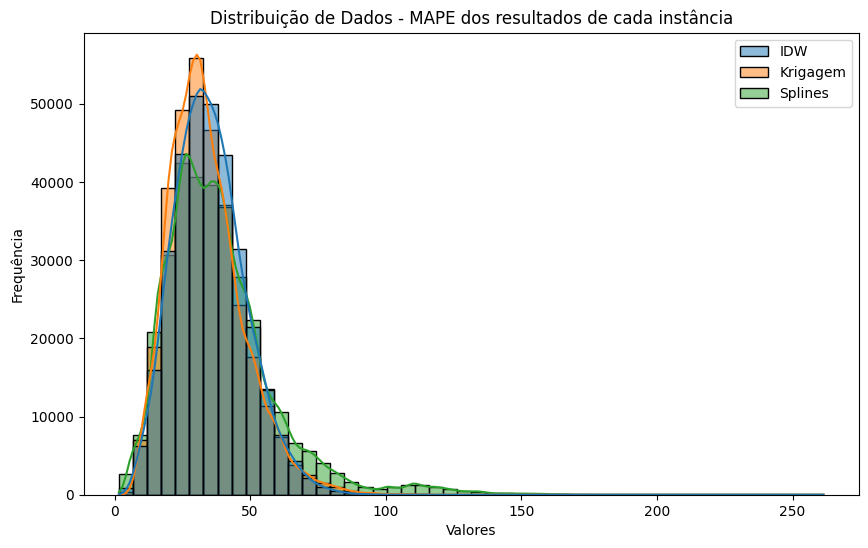

In [22]:

# Criação do gráfico
plt.figure(figsize=(10, 6))
sns.histplot(data=df, bins=50, kde=True)

# Adição de títulos e rótulos
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.title('Distribuição de Dados - MAPE dos resultados de cada instância')

# Mostrar gráfico
plt.show()
